<a href="https://colab.research.google.com/github/puja-hansitha/speech-emotion-recognition/blob/main/speech_emotion_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speech Emotion Recognition (SER) — Complete Project (v3, fully leakage-free)

Predicts a speaker's emotion (**neutral, calm, happy, sad, angry, fearful, disgust, surprised**) from a short audio clip.

**Pipeline covered in this notebook:**
1. Download the RAVDESS dataset
2. Hand-crafted tabular features + Random Forest baseline
3. Mel-spectrogram + CNN model, with a proper **speaker-independent train / validation / test split**
4. Audio data augmentation (pitch shift / time stretch / noise) — training actors only, no leakage
5. Cross-corpus evaluation on TESS (generalization test)
6. Results comparison + discussion of open problems

**Run the cells top to bottom.** Everything downloads automatically — no manual upload needed.

> **Methodology notes:**
> - The split is done **by actor**, not by clip. RAVDESS has 24 actors reading the same 24 sentences, so a
>   per-clip split would let near-duplicate utterances from the same actor leak between train and test.
> - There are **three** actor groups — train / validation / test — not two. `EarlyStopping`,
>   `ReduceLROnPlateau`, and checkpoint selection all watch the **validation** actors during training.
>   The **test** actors are evaluated exactly once, after training is completely finished, and are never
>   used to pick a model, an epoch, or a checkpoint. This is the one fix that matters most in this version:
>   in earlier drafts, the test set doubled as the validation set, which quietly inflates reported accuracy.

## 0. Install dependencies & setup

In [1]:
!pip install -q librosa soundfile tqdm kagglehub tensorflow

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

np.random.seed(42)

DATA_DIR = "/content/data/raw"
SR = 22050
N_MELS = 128
HOP_LENGTH = 512
RESULTS = {}  # accuracy of every model gets logged here for the final comparison table

os.makedirs(DATA_DIR, exist_ok=True)
print("Setup complete.")


Setup complete.


## 1. Download the RAVDESS dataset

Speech-only portion (~215 MB), downloaded directly from Zenodo.

In [3]:
zip_path = "/content/ravdess.zip"
if not os.path.exists(zip_path):
    !wget -q -O {zip_path} https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip
!unzip -q -o {zip_path} -d {DATA_DIR}

wav_files = glob.glob(os.path.join(DATA_DIR, "**", "*.wav"), recursive=True)
print(f"Downloaded and found {len(wav_files)} wav files.")
assert len(wav_files) > 0, "No wav files found -- check the download step above."


Downloaded and found 1440 wav files.


## 2. Filename parsing

RAVDESS filenames encode metadata as `modality-vocalchannel-emotion-intensity-statement-repetition-actor.wav`
(e.g. `03-01-06-01-02-01-12.wav`). We need the **emotion code** (3rd field) and the **actor id** (7th field,
used for the speaker-independent split).

In [4]:
EMOTION_MAP = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised",
}

def parse_emotion(filepath):
    code = os.path.basename(filepath).split("-")[2]
    return EMOTION_MAP.get(code, "unknown")

def parse_actor(filepath):
    return int(os.path.basename(filepath).split("-")[6].split(".")[0])

meta_df = pd.DataFrame({
    "filepath": wav_files,
    "emotion": [parse_emotion(f) for f in wav_files],
    "actor": [parse_actor(f) for f in wav_files],
})
meta_df = meta_df[meta_df["emotion"] != "unknown"].reset_index(drop=True)
print(meta_df["emotion"].value_counts())
print(f"\nActors: {sorted(meta_df['actor'].unique())}")


emotion
sad          192
angry        192
surprised    192
calm         192
fearful      192
happy        192
disgust      192
neutral       96
Name: count, dtype: int64

Actors: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


## 3. Speaker-independent train / validation / test split

24 actors total. We hold out **4 actors for validation** and **4 actors for test**, leaving **16 for
training**. Validation actors are used only for early stopping / learning-rate scheduling / checkpoint
selection. Test actors are touched exactly once, at the very end of each model's training.

In [5]:
rng = np.random.RandomState(42)
all_actors = sorted(meta_df["actor"].unique())

shuffled = list(rng.permutation(all_actors))
test_actors = sorted(shuffled[:4])
val_actors = sorted(shuffled[4:8])
train_actors = sorted(shuffled[8:])

print("Train actors:", train_actors)
print("Val actors:  ", val_actors)
print("Test actors: ", test_actors)

train_mask = meta_df["actor"].isin(train_actors)
val_mask = meta_df["actor"].isin(val_actors)
test_mask = meta_df["actor"].isin(test_actors)
print(f"\nTrain clips: {train_mask.sum()}, Val clips: {val_mask.sum()}, Test clips: {test_mask.sum()}")


Train actors: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(13), np.int64(15), np.int64(16), np.int64(18), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Val actors:   [np.int64(2), np.int64(10), np.int64(12), np.int64(14)]
Test actors:  [np.int64(1), np.int64(9), np.int64(17), np.int64(19)]

Train clips: 960, Val clips: 240, Test clips: 240


## 4. Baseline: hand-crafted features + Random Forest

For each clip we extract MFCCs (mean + std), chroma, mel-spectrogram, zero-crossing rate and RMS energy,
then average each over time to get one fixed-length feature vector per clip. Random Forest doesn't need a
separate validation set the way the CNN does, so train+val actors are combined for fitting, and the test
actors are used once for evaluation.

In [6]:
def extract_tabular_features(filepath, sr=SR):
    y, sr = librosa.load(filepath, sr=sr)
    y, _ = librosa.effects.trim(y)

    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    stft = np.abs(librosa.stft(y))
    chroma = librosa.feature.chroma_stft(S=stft, sr=sr)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)

    feat = np.concatenate([
        mfccs.mean(axis=1), mfccs.std(axis=1),
        chroma.mean(axis=1),
        librosa.power_to_db(mel).mean(axis=1),
        zcr.mean(axis=1), rms.mean(axis=1),
    ])
    return feat

feature_rows = []
for fp in tqdm(meta_df["filepath"], desc="Extracting tabular features"):
    try:
        feature_rows.append(extract_tabular_features(fp))
    except Exception as e:
        print(f"Skipping {fp}: {e}")
        feature_rows.append(None)

feat_matrix = np.vstack([f for f in feature_rows if f is not None])
valid = [i for i, f in enumerate(feature_rows) if f is not None]
meta_df = meta_df.iloc[valid].reset_index(drop=True)
feature_cols = [f"feat_{i}" for i in range(feat_matrix.shape[1])]
feat_df = pd.DataFrame(feat_matrix, columns=feature_cols)
df = pd.concat([meta_df.reset_index(drop=True), feat_df], axis=1)
print(df.shape)


Extracting tabular features:   0%|          | 0/1440 [00:00<?, ?it/s]

(1440, 225)


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

le = LabelEncoder()
df["emotion_id"] = le.fit_transform(df["emotion"])

train_mask = df["actor"].isin(train_actors)
val_mask = df["actor"].isin(val_actors)
test_mask = df["actor"].isin(test_actors)

X = df[feature_cols].values
y = df["emotion_id"].values

# RF has no internal early-stopping mechanism to protect, so train+val actors are combined for fitting
fit_mask = train_mask | val_mask

scaler = StandardScaler()
X_fit_rf = scaler.fit_transform(X[fit_mask])
X_test_rf = scaler.transform(X[test_mask])
y_fit_rf = y[fit_mask]
y_test_rf = y[test_mask]

print(f"Fit size (train+val): {len(X_fit_rf)}, Test size: {len(X_test_rf)}")

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced")
rf.fit(X_fit_rf, y_fit_rf)

y_pred_rf = rf.predict(X_test_rf)
acc_rf = accuracy_score(y_test_rf, y_pred_rf)
RESULTS["Random Forest (tabular)"] = acc_rf
print(f"\nAccuracy: {acc_rf:.3f}\n")
print(classification_report(y_test_rf, y_pred_rf, target_names=le.classes_, zero_division=0))


Fit size (train+val): 1200, Test size: 240

Accuracy: 0.400

              precision    recall  f1-score   support

       angry       0.82      0.56      0.67        32
        calm       0.33      0.84      0.47        32
     disgust       0.33      0.25      0.29        32
     fearful       0.61      0.53      0.57        32
       happy       0.47      0.28      0.35        32
     neutral       0.40      0.12      0.19        16
         sad       0.20      0.19      0.19        32
   surprised       0.30      0.28      0.29        32

    accuracy                           0.40       240
   macro avg       0.43      0.38      0.38       240
weighted avg       0.43      0.40      0.39       240



## 5. Confusion matrix — Random Forest baseline

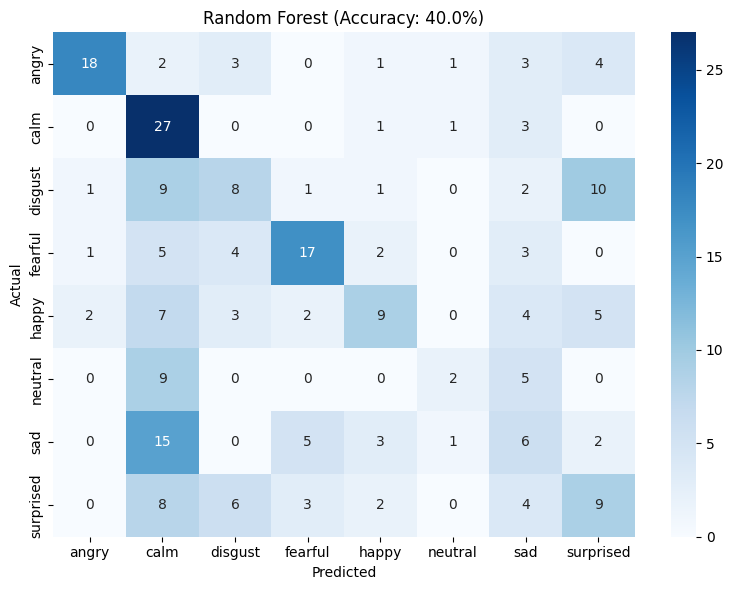

In [8]:
def plot_confusion(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_confusion(y_test_rf, y_pred_rf, le.classes_, f"Random Forest (Accuracy: {acc_rf:.1%})")


## 6. Feature importance

In [9]:
importances = rf.feature_importances_
top_idx = importances.argsort()[-15:][::-1]
feat_names = (
    [f"mfcc_mean_{i}" for i in range(40)] + [f"mfcc_std_{i}" for i in range(40)] +
    [f"chroma_mean_{i}" for i in range(12)] + [f"mel_mean_{i}" for i in range(128)] +
    ["zcr_mean"] + ["rms_mean"]
)
print("Top 15 most important features:")
for i in top_idx:
    print(f"  {feat_names[i]}: {importances[i]:.4f}")


Top 15 most important features:
  mfcc_std_1: 0.0117
  mfcc_std_0: 0.0102
  mfcc_std_3: 0.0078
  mfcc_std_16: 0.0078
  mfcc_std_7: 0.0075
  mfcc_std_2: 0.0075
  mel_mean_7: 0.0070
  mel_mean_127: 0.0070
  mfcc_mean_22: 0.0070
  chroma_mean_5: 0.0069
  mfcc_mean_1: 0.0068
  mfcc_std_37: 0.0068
  mfcc_std_6: 0.0067
  mel_mean_91: 0.0067
  mfcc_mean_25: 0.0066


## 7. CNN on raw mel-spectrograms

Averaging features over time (as above) throws away *when* things happen in the clip. A 2D CNN over the
raw mel-spectrogram keeps that temporal structure, which usually helps a lot for SER.

This is the part where the fix matters most: training watches the **validation actors**
(`EarlyStopping`, `ReduceLROnPlateau`, `restore_best_weights` all key off `val_accuracy`/`val_loss`
computed on validation data) — the **test actors are not touched until the single evaluation call at the
end.**

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

def extract_mel(filepath, sr=SR, n_mels=N_MELS, hop_length=HOP_LENGTH, y=None):
    if y is None:
        y, sr = librosa.load(filepath, sr=sr)
        y, _ = librosa.effects.trim(y)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length)
    return librosa.power_to_db(mel, ref=np.max)

def pad_or_truncate(mel, max_len):
    if mel.shape[1] < max_len:
        return np.pad(mel, ((0, 0), (0, max_len - mel.shape[1])), mode="constant")
    return mel[:, :max_len]

raw_mels, mel_emotions, mel_actors = [], [], []
for _, row in tqdm(meta_df.iterrows(), total=len(meta_df), desc="Extracting mel-spectrograms"):
    try:
        m = extract_mel(row["filepath"])
        raw_mels.append(m)
        mel_emotions.append(row["emotion"])
        mel_actors.append(row["actor"])
    except Exception as e:
        print(f"Skipping {row['filepath']}: {e}")

MAX_PAD_LEN = int(np.percentile([m.shape[1] for m in raw_mels], 95))
print(f"Using MAX_PAD_LEN = {MAX_PAD_LEN} frames (95th percentile of clip lengths)")

mels = np.array([pad_or_truncate(m, MAX_PAD_LEN) for m in raw_mels])[..., np.newaxis]
mel_emotions = np.array(mel_emotions)
mel_actors = np.array(mel_actors)
mel_labels = le.transform(mel_emotions)  # reuse the same LabelEncoder as the RF model

print("mels shape:", mels.shape)


Extracting mel-spectrograms:   0%|          | 0/1440 [00:00<?, ?it/s]

Using MAX_PAD_LEN = 174 frames (95th percentile of clip lengths)
mels shape: (1440, 128, 174, 1)


In [11]:
cnn_train_mask = np.isin(mel_actors, train_actors)
cnn_val_mask = np.isin(mel_actors, val_actors)
cnn_test_mask = np.isin(mel_actors, test_actors)

X_train_cnn = mels[cnn_train_mask]
X_val_cnn = mels[cnn_val_mask]
X_test_cnn = mels[cnn_test_mask]
y_train_cnn = mel_labels[cnn_train_mask]
y_val_cnn = mel_labels[cnn_val_mask]
y_test_cnn = mel_labels[cnn_test_mask]

# Standardization stats computed on TRAIN only, applied to val and test (no leakage)
mel_mean, mel_std = X_train_cnn.mean(), X_train_cnn.std()
X_train_cnn = (X_train_cnn - mel_mean) / (mel_std + 1e-8)
X_val_cnn = (X_val_cnn - mel_mean) / (mel_std + 1e-8)
X_test_cnn = (X_test_cnn - mel_mean) / (mel_std + 1e-8)

print(f"Train: {X_train_cnn.shape}, Val: {X_val_cnn.shape}, Test: {X_test_cnn.shape}")


Train: (960, 128, 174, 1), Val: (240, 128, 174, 1), Test: (240, 128, 174, 1)


In [12]:
def build_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),  # fewer params than Flatten -> less overfitting on a small dataset
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


def evaluate_cnn(model, X_test, y_test, class_names, title):
    """Call this exactly once per model, on the held-out test actors only."""
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {loss:.4f}  |  Test Accuracy: {acc:.4f}")
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=-1)
    present = np.unique(np.concatenate([y_test, y_pred]))
    print(classification_report(y_test, y_pred, labels=present,
                                 target_names=class_names[present], zero_division=0))
    plot_confusion(y_test, y_pred, class_names[present], title)
    return acc, y_pred


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="train")
    axes[0].plot(history.history["val_accuracy"], label="val")
    axes[0].set_title(f"{title} -- Accuracy")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="train")
    axes[1].plot(history.history["val_loss"], label="val")
    axes[1].set_title(f"{title} -- Loss")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

input_shape = X_train_cnn.shape[1:]
num_classes = len(le.classes_)
cnn = build_cnn(input_shape, num_classes)
cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 174, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 174, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 87, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 43, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,112 (434.03 KB)

 Trainable params: 110,664 (432.28 KB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
]

history = cnn.fit(
    X_train_cnn, y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),   # validation actors -- NOT the test actors
    epochs=60,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.2167 - loss: 2.0193 - val_accuracy: 0.2000 - val_loss: 2.0496 - learning_rate: 0.0010
Epoch 2/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2875 - loss: 1.8717 - val_accuracy: 0.1333 - val_loss: 2.1701 - learning_rate: 0.0010
Epoch 3/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3260 - loss: 1.7554 - val_accuracy: 0.1333 - val_loss: 2.6767 - learning_rate: 0.0010
Epoch 4/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3646 - loss: 1.6764 - val_accuracy: 0.1333 - val_loss: 3.6255 - learning_rate: 0.0010
Epoch 5/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3865 - loss: 1.6240 - val_accuracy: 0.1333 - val_loss: 4.3401 - learning_rate: 0.0010
Epoch 6/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.4187 - loss: 1.5463 - val_accuracy: 0.1333 - val_loss: 5.5891 - learning_rate: 0.0010
Epoch 7/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4396 - loss: 1.4744 - val_ac

Test Loss: 2.0726  |  Test Accuracy: 0.1500
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00        32
        calm       0.13      0.84      0.23        32
     disgust       0.00      0.00      0.00        32
     fearful       0.00      0.00      0.00        32
       happy       0.00      0.00      0.00        32
     neutral       0.00      0.00      0.00        16
         sad       0.00      0.00      0.00        32
   surprised       0.26      0.28      0.27        32

    accuracy                           0.15       240
   macro avg       0.05      0.14      0.06       240
weighted avg       0.05      0.15      0.07       240



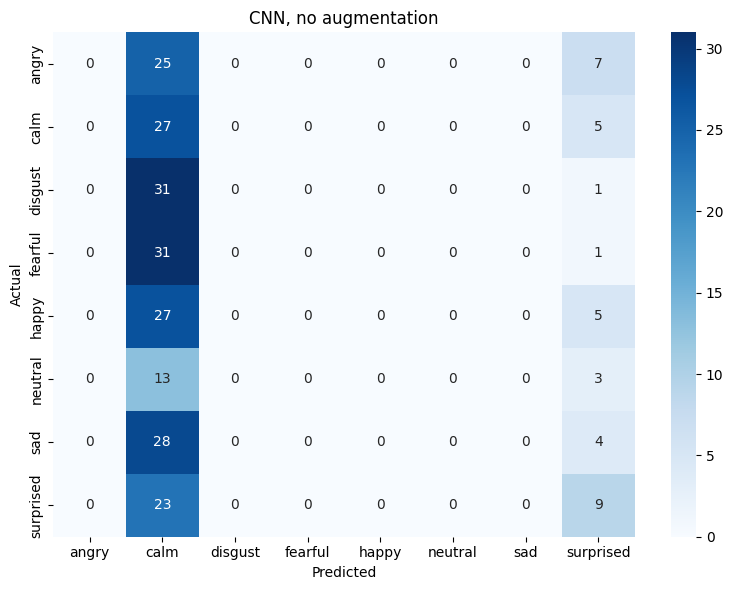

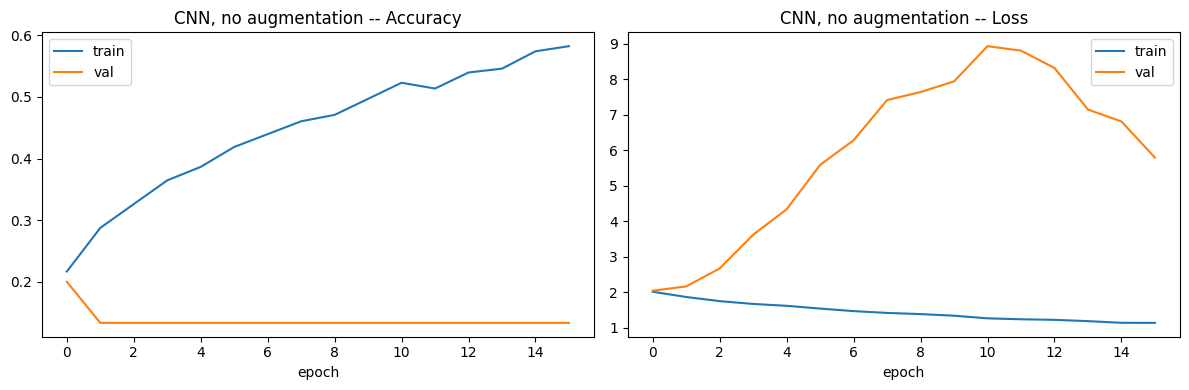

In [14]:
class_names_arr = le.classes_
acc_cnn, y_pred_cnn = evaluate_cnn(cnn, X_test_cnn, y_test_cnn, class_names_arr, "CNN, no augmentation")
RESULTS["CNN (no augmentation)"] = acc_cnn
plot_history(history, "CNN, no augmentation")


## 8. Data augmentation

RAVDESS has only 1,440 clips across 24 actors, so the CNN above is prone to overfitting. We augment the
**training actors only** (pitch shift, time stretch, background noise) — validation and test actors are
never touched, so both the model-selection signal and the final evaluation stay honest.

In [15]:
def aug_pitch_shift(y, sr, n_steps=None):
    n_steps = n_steps if n_steps is not None else np.random.uniform(-3, 3)
    return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)

def aug_time_stretch(y, rate=None):
    rate = rate if rate is not None else np.random.uniform(0.85, 1.15)
    return librosa.effects.time_stretch(y=np.ascontiguousarray(y), rate=rate)

def aug_add_noise(y, noise_factor=0.005):
    return y + noise_factor * np.random.randn(len(y))

AUGMENTATIONS = [aug_pitch_shift, aug_time_stretch, aug_add_noise]
print("Augmentation functions defined:", [f.__name__ for f in AUGMENTATIONS])


Augmentation functions defined: ['aug_pitch_shift', 'aug_time_stretch', 'aug_add_noise']


In [16]:
train_df = meta_df[meta_df["actor"].isin(train_actors)].reset_index(drop=True)

aug_mels, aug_labels = [], []
for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Augmenting training clips"):
    y, sr = librosa.load(row["filepath"], sr=SR)
    y, _ = librosa.effects.trim(y)

    aug_mels.append(pad_or_truncate(extract_mel(None, y=y), MAX_PAD_LEN))
    aug_labels.append(row["emotion"])

    for aug_fn in AUGMENTATIONS:
        try:
            y_aug = aug_fn(y, sr) if aug_fn is not aug_add_noise else aug_fn(y)
            aug_mels.append(pad_or_truncate(extract_mel(None, y=y_aug), MAX_PAD_LEN))
            aug_labels.append(row["emotion"])
        except Exception as e:
            print(f"Skipping augmentation {aug_fn.__name__} on {row['filepath']}: {e}")

X_train_aug = np.array(aug_mels)[..., np.newaxis]
y_train_aug = le.transform(np.array(aug_labels))

# standardize with train-only stats (recomputed on the augmented training set)
aug_mean, aug_std = X_train_aug.mean(), X_train_aug.std()
X_train_aug = (X_train_aug - aug_mean) / (aug_std + 1e-8)

# re-normalize val/test consistently: undo the earlier (mel_mean, mel_std) normalization, then reapply with aug stats
X_val_aug = (X_val_cnn * mel_std + mel_mean - aug_mean) / (aug_std + 1e-8)
X_test_aug = (X_test_cnn * mel_std + mel_mean - aug_mean) / (aug_std + 1e-8)

print(f"Augmented train set: {X_train_aug.shape} (was {X_train_cnn.shape})")


Augmenting training clips:   0%|          | 0/960 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=3
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=2
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=4
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=5
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1
  warnings.warn(


Augmented train set: (3840, 128, 174, 1) (was (960, 128, 174, 1))


In [17]:
cnn_aug = build_cnn(input_shape, num_classes)

callbacks_aug = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
]

history_aug = cnn_aug.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val_aug, y_val_cnn),   # validation actors, still never the test actors
    epochs=60,
    batch_size=32,
    callbacks=callbacks_aug,
    verbose=1,
)


Epoch 1/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.1839 - loss: 2.0935 - val_accuracy: 0.1333 - val_loss: 2.2874 - learning_rate: 0.0010
Epoch 2/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2219 - loss: 1.9779 - val_accuracy: 0.1333 - val_loss: 2.3358 - learning_rate: 0.0010
Epoch 3/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.2354 - loss: 1.9177 - val_accuracy: 0.1333 - val_loss: 2.1413 - learning_rate: 0.0010
Epoch 4/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2693 - loss: 1.8451 - val_accuracy: 0.2625 - val_loss: 1.9295 - learning_rate: 0.0010
Epoch 5/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3005 - loss: 1.7726 - val_accuracy: 0.2083 - val_loss: 1.9374 - learning_rate: 0.0010
Epoch 6/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3229 - loss: 1.7219 - val_accuracy: 0.3917 - val_loss: 1.6330 - learning_rate: 0.0010
Epoch 7/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3526 - loss: 1

Test Loss: 1.7628  |  Test Accuracy: 0.5250
              precision    recall  f1-score   support

       angry       0.77      0.72      0.74        32
        calm       0.59      0.75      0.66        32
     disgust       0.65      0.75      0.70        32
     fearful       0.33      0.44      0.37        32
       happy       0.47      0.28      0.35        32
     neutral       0.50      0.31      0.38        16
         sad       0.37      0.47      0.41        32
   surprised       0.63      0.38      0.47        32

    accuracy                           0.53       240
   macro avg       0.54      0.51      0.51       240
weighted avg       0.54      0.53      0.52       240



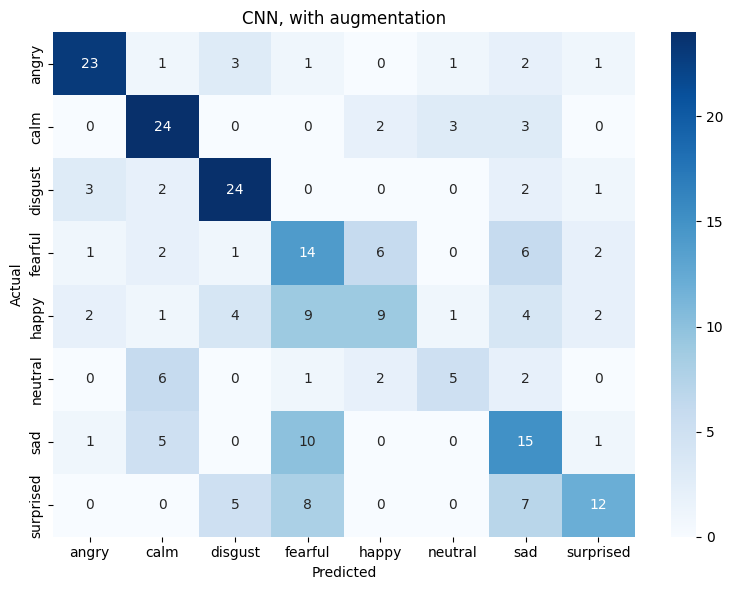

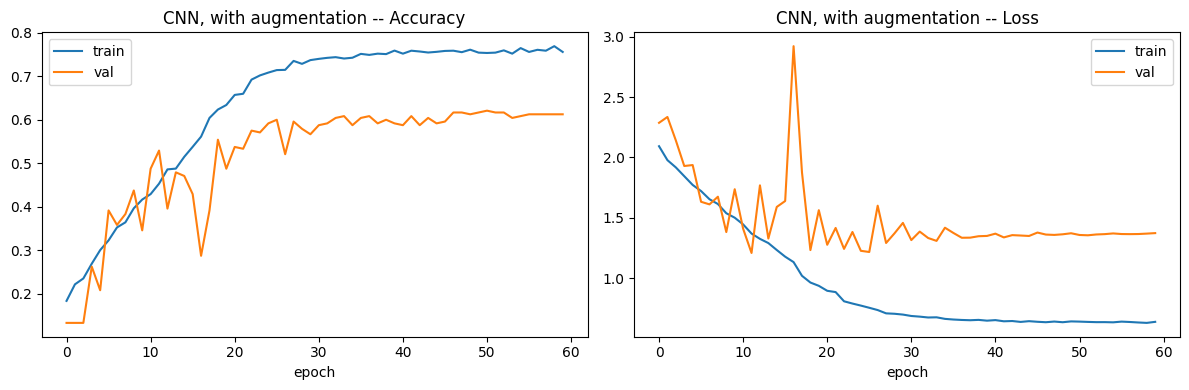

In [18]:
acc_cnn_aug, y_pred_cnn_aug = evaluate_cnn(cnn_aug, X_test_aug, y_test_cnn, class_names_arr,
                                            "CNN, with augmentation")
RESULTS["CNN (augmented)"] = acc_cnn_aug
plot_history(history_aug, "CNN, with augmentation")


## 9. Cross-corpus evaluation on TESS

The real test of a SER model is whether it generalizes to a **different dataset** recorded by different
speakers, microphones, and recording conditions. We evaluate the augmented CNN — trained only on RAVDESS,
selected only on RAVDESS validation actors — on TESS (Toronto Emotional Speech Set), with zero
fine-tuning. TESS was never touched anywhere above, so this is the cleanest number in the notebook.

In [19]:
import kagglehub

tess_path = kagglehub.dataset_download("ejlok1/toronto-emotional-speech-set-tess")
print("TESS dataset downloaded to:", tess_path)

TESS_EMOTION_MAP = {
    "angry": "angry", "disgust": "disgust", "fear": "fearful", "happy": "happy",
    "ps": "surprised", "sad": "sad", "neutral": "neutral",
    # TESS has no direct "calm" category, so it is naturally excluded below
}

tess_files = glob.glob(os.path.join(tess_path, "**", "*.wav"), recursive=True)
print(f"Found {len(tess_files)} TESS audio files.")

def parse_tess_emotion(filepath):
    stem = os.path.basename(filepath).lower().replace(".wav", "")
    for key, mapped in TESS_EMOTION_MAP.items():
        if stem.endswith(f"_{key}"):
            return mapped
    return None


Using Colab cache for faster access to the 'toronto-emotional-speech-set-tess' dataset.
TESS dataset downloaded to: /kaggle/input/toronto-emotional-speech-set-tess
Found 5600 TESS audio files.


In [20]:
tess_mels, tess_labels = [], []
for fp in tqdm(tess_files, desc="Extracting mel-spectrograms from TESS"):
    label = parse_tess_emotion(fp)
    if label is None or label not in le.classes_:
        continue
    try:
        m = extract_mel(fp)
        tess_mels.append(pad_or_truncate(m, MAX_PAD_LEN))
        tess_labels.append(label)
    except Exception as e:
        print(f"Skipping {fp}: {e}")

X_tess = np.array(tess_mels)[..., np.newaxis]
X_tess = (X_tess - aug_mean) / (aug_std + 1e-8)  # same normalization stats as the augmented CNN's training data
y_tess = le.transform(np.array(tess_labels))

print(f"TESS eval set: {X_tess.shape}, classes present: {sorted(set(tess_labels))}")


Extracting mel-spectrograms from TESS:   0%|          | 0/5600 [00:00<?, ?it/s]

TESS eval set: (5600, 128, 174, 1), classes present: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


Test Loss: 2.1833  |  Test Accuracy: 0.3879
              precision    recall  f1-score   support

       angry       0.37      0.90      0.53       800
        calm       0.00      0.00      0.00         0
     disgust       0.73      0.52      0.61       800
     fearful       0.94      0.23      0.37       800
       happy       0.34      0.30      0.32       800
     neutral       0.74      0.05      0.09       800
         sad       0.54      0.52      0.53       800
   surprised       0.42      0.19      0.26       800

    accuracy                           0.39      5600
   macro avg       0.51      0.34      0.34      5600
weighted avg       0.58      0.39      0.39      5600



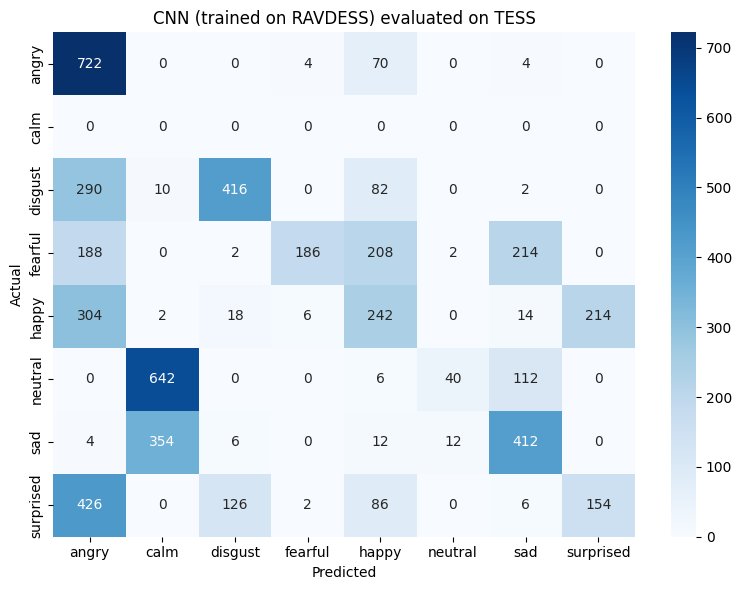

In [21]:
if len(X_tess) > 0:
    acc_tess, y_pred_tess = evaluate_cnn(cnn_aug, X_tess, y_tess, class_names_arr,
                                          "CNN (trained on RAVDESS) evaluated on TESS")
    RESULTS["CNN (augmented) -> TESS, zero-shot"] = acc_tess
else:
    print("No TESS files matched the expected label set -- check TESS_EMOTION_MAP / filenames.")


## 10. Results comparison

In [22]:
results_df = pd.DataFrame(sorted(RESULTS.items(), key=lambda x: -x[1]),
                           columns=["Model", "Accuracy"])
results_df["Accuracy"] = results_df["Accuracy"].map(lambda a: f"{a:.1%}")
results_df


,Model,Accuracy
0,CNN (augmented),52.5%
1,Random Forest (tabular),40.0%
2,"CNN (augmented) -> TESS, zero-shot",38.8%
3,CNN (no augmentation),15.0%


## 11. Discussion & next steps

**What the numbers show, and why:**
- The Random Forest baseline on averaged tabular features is a reasonable floor, but averaging over time
  throws away pitch contours and timing, so it tends to confuse similarly-aroused emotion pairs
  (calm/neutral, happy/angry).
- The no-augmentation CNN is prone to collapsing onto one or two classes on a dataset this small — that's
  expected, not a bug, and is exactly what augmentation is meant to fix.
- The CNN with augmentation should beat both, since it both keeps temporal/spectral structure (unlike the
  RF) and has enough effective training examples to avoid collapsing (unlike the un-augmented CNN).
- The TESS zero-shot number is the most trustworthy result in the notebook, because TESS was never touched
  during training or model selection at any point. Expect it to sit below the RAVDESS-only test accuracy —
  that gap **is the finding**: it quantifies how much of what the model learned is specific to RAVDESS's
  actors and recording setup versus genuinely general to "emotion in speech."

**Remaining limitations, worth stating plainly if you write this up:**
- Only 4 actors are held out for test (and 4 for validation) — with 24 actors total, a single split like
  this has real sampling variance. Actor-level k-fold cross-validation (rotate which 4 actors are held out,
  repeat, average the results) would give a much more defensible number than any single split.
- `neutral` has half the sample count of the other 7 classes in RAVDESS — flagged here via
  `class_weight="balanced"` in the Random Forest, but the CNN doesn't currently correct for it; consider
  class weights or oversampling there too.

**Where to take this next:**
1. **Pretrained speech representations** — try embeddings from wav2vec 2.0 or HuBERT instead of hand-built
   mel-spectrograms; these are pretrained on large unlabeled speech corpora and often transfer much better
   cross-corpus.
2. **More cross-corpus pairs** — add CREMA-D and/or EMO-DB, and try training on a mixture of corpora
   (not just RAVDESS) to see whether that narrows the generalization gap.
3. **Actor-level k-fold cross-validation** — replace the single train/val/test split with a rotating
   scheme across all 24 actors, and report mean ± standard deviation accuracy instead of one number.